## CitySeer: Métricas Configuracionais do Espaço Urbano

**AUTORIA:** [REDE MOB](https://www.redemob.com.br/), com base nos [notebooks ilustrativos do pacote cityseer](https://benchmark-urbanism.github.io/cityseer-examples/).

`cityseer-api` é uma ferramenta digital desenvolvida para ajudar na análise detalhada de ruas e do uso do solo nas cidades. Seu principal objetivo é compreender como a forma urbana influencia a vitalidade dos bairros, especialmente do ponto de vista de quem anda a pé.

Com essa ferramenta, é possível medir a importância de diferentes ruas dentro da rede viária, avaliar o acesso a diferentes tipos de uso do solo (como moradia, comércio, serviços), e entender como essas relações espaciais se organizam dentro de um bairro ou cidade. As análises levam em conta a distância real de caminhada e a direção pela qual as pessoas se aproximam de cada lugar, oferecendo uma visão mais precisa da acessibilidade urbana.

Além disso, o `cityseer-api` permite trabalhar com dados de mapas abertos e pode ser usado para analisar cidades pequenas ou grandes. Ele ajuda planejadores urbanos, arquitetos e pesquisadores a entenderem melhor como o desenho das ruas e a distribuição dos usos do solo influenciam a dinâmica dos espaços urbanos.

**PANORAMA**
- Análises espaciais de alta resolução, com janelas móveis locais e distâncias reais de rede, para maior sensibilidade ao contexto urbano.

- Cálculo local de centralidades de rede, com caminhos mais curtos ou simples, incluindo variantes contínuas e métricas específicas como harmonic closeness.

- Medições de acessibilidade e uso misto do solo, com agregações dinâmicas e direcionais, adaptáveis a diferentes estruturas de rede.

- Integração de centralidade, acessibilidade e estatísticas, gerando dados multivariados úteis para ciência de dados e aprendizado de máquina.

- Limpeza da rede, para reduzir distorções topológicas e melhorar a precisão analítica.

- Desempenho otimizado, permitindo análise eficiente de redes grandes e detalhadas.

**MAIS INFORMAÇÕES:**
- **Importante**: a biblioteca foi concebida com ênfase em pedestres, de maneira que ela não leva em conta a direcionalidade da rede, mas, em cidades como o Rio de Janeiro, por exemplo, há muitas vias de mão única, o que pode em alguma medida distorcer o resultado das métricas em algum contexto. Para pedestres, isso não seria um problema, dado que eles não estão confinados ao sentido do tráfego. No entanto, se a biblioteca for utilizada para compreender o ponto de vista dos usuários do automóvel, os resultados podem não ser tao precisos. Mas, como próximo de uma via de mão única normalmente há uma via em sentido contrário, em uma análise mais além do nível da vizinhança, os resultados devem ainda ser informativos.
        
    - **# TO DO**: computar betweenness na escala de uma grande regiã como uma Área de Planejamento do Rio de Janeiro para fazer uma espécie de benchmark dos resultados

**LINKS DE INTERESSE:**
- [Artigo de origem do cityseer](https://journals.sagepub.com/doi/full/10.1177/23998083221133827)
- Detalhes teóricos para os mais curiosos podem ser encontrados em uma vasta literatura técnica e acadêmica, mas, de início, pode ser interessante começar pelas [notas de aula do professor Romulo Krafta](https://www.researchgate.net/profile/Romulo-Krafta/publication/265597665_NOTAS_DE_AULA_DE_MORFOLOGIA_URBANA/links/58cfdeb7458515b6ed8c457f/NOTAS-DE-AULA-DE-MORFOLOGIA-URBANA.pdf), as quais foram transformadas em livro.

- **#TO DO**: mais links para materiais técnicos e acadêmicos gerais, externos, de referência a respeito do conteúdo abordado


# Instruções

yada yada yada

# Parâmetros Definidos Pelo Usuário

In [1]:
# Forneça código do IBGE da cidade, ou lista de códigos
MUNI_CODES      = (3300704,)

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [2]:
# Standard library imports
from itertools import combinations
import os
from pathlib import Path
import pickle
import sys
import tempfile
from typing import List
import zipfile

# Third-party library imports
from cityseer.metrics import networks, layers
from cityseer.tools import io, graphs
import contextily as cx
import geobr
import geopandas as gpd
from libpysal.cg import voronoi_frames
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from shapely.geometry import LineString
from sklearn.preprocessing import MinMaxScaler
from tobler.area_weighted import area_interpolate
from tqdm import tqdm


INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

sys.path.append(os.path.abspath(".."))

In [4]:
OUT_DIR         = Path("../outputs/cityseer")

# Getting Valid Study Area

In [5]:
place = pd.concat([
    geobr.read_municipality(idx)
    for idx in MUNI_CODES
])

crs = place.estimate_utm_crs(datum_name='SIRGAS 2000')
place = place.to_crs(crs)

study_area_bounds = place.geometry.concave_hull(ratio=.3).squeeze()

# Graph Prepation

In [6]:
G = io.osm_graph_from_poly(
    study_area_bounds,
    poly_crs_code=crs.to_epsg(),
    to_crs_code=crs.to_epsg(),
    simplify=True,
    cycleways=False,
    busways=False,
    green_footways=False,
    green_service_roads=False,

)

INFO:cityseer.tools.graphs:Generating interpolated edge geometries.
100%|██████████| 47650/47650 [00:01<00:00, 33416.50it/s]
INFO:cityseer.tools.io:Converting networkX graph to CRS code 31983.
INFO:cityseer.tools.io:Processing node x, y coordinates.
100%|██████████| 42871/42871 [00:00<00:00, 424016.64it/s]
INFO:cityseer.tools.io:Processing edge geom coordinates, if present.
100%|██████████| 47650/47650 [00:07<00:00, 6092.44it/s]
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 42871/42871 [00:06<00:00, 6404.68it/s] 
INFO:cityseer.tools.util:Creating edges STR tree.
100%|██████████| 17907/17907 [00:02<00:00, 7030.79it/s]
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 17631/17631 [00:00<00:00, 457794.12it/s]
INFO:cityseer.tools.graphs:Removing dangling nodes.
INFO:cityseer.tools.graphs:Removing filler nodes.
100%|██████████| 12990/12990 [00:00<00:00, 382062.40it/s]
INFO:cityseer.tools.util:Creating edges STR tree.
100%|██████████| 17356/17356 [00:00<

In [7]:
OUT_PICKLE    = (
    OUT_DIR
    / f"simplified_graph_{'-'.join(str(m) for m in MUNI_CODES)}.gpickle"
    )


with open(OUT_PICKLE, 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

#with open(OUT_PICKLE, 'rb') as f:
#    G = pickle.load(f)

In [8]:
G_dual = graphs.nx_to_dual(G)

INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 15175/15175 [00:00<00:00, 19462.14it/s]
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 15175/15175 [00:46<00:00, 329.76it/s]


# Graph Metrics

## Base Params

In [9]:
def max_cutoff_distance(polygongeometry):
    """A function which finds the approximate longest line in an input polygon geometry"""
    all_vertex_coordinates = list(polygongeometry.exterior.coords)
    all_lines = [LineString(vertexpair) for vertexpair in combinations(all_vertex_coordinates, 2)]
    
    #Intersects/clips each of them with the input polygon geometry
    # Then, extracts the lines, other possible intersection outputs
    # can be geometry collections and points if Polgygon is irregular
    clipped = [polygongeometry.intersection(line) for line in all_lines]
    clipped = [line for line in clipped if isinstance(line, LineString)]
    
    longest_line = max(clipped, key=lambda x: x.length)
    
    return longest_line.length


# Optionally, use segmentize from Shapely (verticies every d distance)
# for more precise computations, but, here, it is 

In [10]:
max_cutoff = max_cutoff_distance(study_area_bounds)

In [11]:
# Considering a node in the center of the study area
# Any node will be at a distance of about half the longest line
max_cutoff / 2 

20420.948732772875

In [12]:
# Cutoffs from local to global
distances = [250, 500, 1000, 2500, 5000, 10_000, 20_000]

## Unweighted Measures

In [13]:
nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 15175/15175 [00:09<00:00, 1628.04it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 32590 items.


### Metric Distances

In [14]:
nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 15175/15175 [01:15<00:00, 200.64it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 250m, Beta: 0.016, Walking Time: 3.1333333333333333 minutes.
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.
INFO:cityseer.config:Distance: 20000m, Beta: 0.0002, Walking Time: 250.0 minutes.


### Angular Distances

In [15]:
nodes_gdf = networks.node_centrality_simplest(
    network_structure=network_structure,
    nodes_gdf=nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 15175/15175 [00:41<00:00, 367.00it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 250m, Beta: 0.016, Walking Time: 3.1333333333333333 minutes.
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.
INFO:cityseer.config:Distance: 20000m, Beta: 0.0002, Walking Time: 250.0 minutes.


In [16]:
OUT_PARQUET    = (
    OUT_DIR
    / f"unweighted_centrality_{'-'.join(str(m) for m in MUNI_CODES)}.parquet"
    )

nodes_gdf.to_parquet(
    OUT_PARQUET
)

#nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

## Weighted Measures

In [17]:
INPUT_DIR = Path("../outputs/sociodemografia")

input_path = (
    INPUT_DIR
    / f'sociodemografia_hex_r9_{"-".join(str(m) for m in MUNI_CODES)}.parquet'
    )
pop_by_hex = gpd.read_parquet(input_path)

INPUT_DIR = Path("../outputs/rais")
input_path = (
    INPUT_DIR
    / f'rais_{"-".join(str(m) for m in MUNI_CODES)}.parquet'
    )
rais = gpd.read_parquet(input_path)

In [18]:
def get_node_weights(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int = 31983
) -> pd.DataFrame:
    """
    Impute attributes from a GeoDataFrame to nodes in an OSMnx graph.

    Returns:
    - DataFrame with attr_cols, indexed as nodes
    """
    gdf, geom_types = validate_input_gdf(gdf, attr_cols)
    node_polygons = create_voronoi_polygons(nodes, study_area, out_crs)

    geometry_handlers = {
        frozenset({'Polygon', 'MultiPolygon'}): handle_polygons_with_area_interpolation,
        frozenset({'Point', 'MultiPoint'}): handle_points_with_spatial_join,
    }

    for geom_type_set, handler in geometry_handlers.items():
        if geom_types.issubset(geom_type_set):
            # Call the handler, but only keep attr_cols and index
            result = handler(nodes.copy(), gdf, node_polygons, attr_cols, out_crs)
            return result[attr_cols]

    raise ValueError("Tipo de geometria não suportado no GeoDataFrame.")


def validate_input_gdf(
    gdf: gpd.GeoDataFrame, attr_cols: List[str]
) -> tuple[gpd.GeoDataFrame, set[str]]:
    """Validate the input GeoDataFrame and attribute columns."""
    if gdf.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    dropped_count = gdf.loc[gdf.geometry.isnull()].shape[0]
    if dropped_count > 0:
        print(
            f"Aviso: {dropped_count} geometria(s) foram descartadas por serem "
            "nulas."
        )
    gdf = gdf.loc[gdf.geometry.notnull()]
    gdf = gdf.fillna(0)
    geom_types = set(gdf.geometry.geom_type.unique())

    for col in attr_cols:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
        if gdf[col].isnull().any():
            invalid_entries = gdf.loc[gdf[col].isnull(), col]
            if not invalid_entries.empty:
                print(
                    f"Aviso: A coluna '{col}' contém entradas inválidas que "
                    f"não puderam ser convertidas para valores numéricos: "
                    f"{invalid_entries.tolist()}"
                )

    return gdf, geom_types


def create_voronoi_polygons(
    nodes: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    out_crs: str | int
) -> gpd.GeoDataFrame:
    """Create Voronoi polygons around nodes."""
    return voronoi_frames(
        nodes.to_crs(out_crs),
        clip=study_area,
        return_input=False,
        as_gdf=True,
    )


def handle_polygons_with_area_interpolation(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle polygons using area interpolation."""
    interpolated = area_interpolate(
        source_df=gdf.to_crs(out_crs),
        target_df=node_polygons,
        extensive_variables=attr_cols,
        allocate_total=True,
    )
    for col in attr_cols:
        nodes[col] = interpolated[col].to_numpy()
    return nodes


def handle_points_with_spatial_join(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle points using spatial join and dissolve."""
    gdf = gdf.to_crs(out_crs)
    joined = gpd.sjoin(node_polygons, gdf, how="left", predicate="contains")
    dissolved = joined.groupby(joined.index).agg(
        {col: "sum" for col in attr_cols}
    )
    for col in attr_cols:
        nodes[col] = dissolved[col].to_numpy()
    return nodes


In [19]:
node_data = {
    'osmid': list(G_dual.nodes()),
    'x': [data['x'] for node, data in G_dual.nodes(data=True)],
    'y': [data['y'] for node, data in G_dual.nodes(data=True)],
}
# Create node GeoDataFrame
node_gdf = gpd.GeoDataFrame(
    node_data,
    crs=31983,
    geometry=gpd.points_from_xy(node_data['x'], node_data['y'])
    )
node_gdf = node_gdf.set_index('osmid')

In [20]:
node_gdf['vinculos'] = get_node_weights(
    node_gdf,
    rais,
    study_area_bounds.buffer(1_000),
    attr_cols=['quantidade_vinculos_ativos'],
    out_crs=31983,
)

node_gdf['estabelecimentos'] = get_node_weights(
    node_gdf,
    rais.assign(quantidade_estabelecimentos=1),
    study_area_bounds.buffer(1_000),
    attr_cols=['quantidade_estabelecimentos'],
    out_crs=31983,
)

node_gdf['habitantes'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['habitantes'],
    out_crs=31983,
)

node_gdf['domicilios'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['domicilios'],
    out_crs=31983,
)

node_gdf['weight'] = node_gdf.habitantes

In [21]:
nbunch = {
    k: {'weight': v}
    for k, v in node_gdf.weight.to_dict().items()
    }

nx.set_node_attributes(
    G_dual,
    nbunch,
)

### Shortest Distance

In [22]:
weighted_nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 15175/15175 [00:08<00:00, 1888.49it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 32590 items.


In [23]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 15175/15175 [01:16<00:00, 199.40it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 250m, Beta: 0.016, Walking Time: 3.1333333333333333 minutes.
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.
INFO:cityseer.config:Distance: 20000m, Beta: 0.0002, Walking Time: 250.0 minutes.


### Angular Distances

In [24]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 15175/15175 [00:39<00:00, 382.18it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 250m, Beta: 0.016, Walking Time: 3.1333333333333333 minutes.
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.
INFO:cityseer.config:Distance: 20000m, Beta: 0.0002, Walking Time: 250.0 minutes.


In [25]:
OUT_PARQUET    = (
    OUT_DIR
    / f"weighted_centrality_{'-'.join(str(m) for m in MUNI_CODES)}.parquet"
    )

weighted_nodes_gdf.to_parquet(
    OUT_PARQUET
)

#weighted_nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

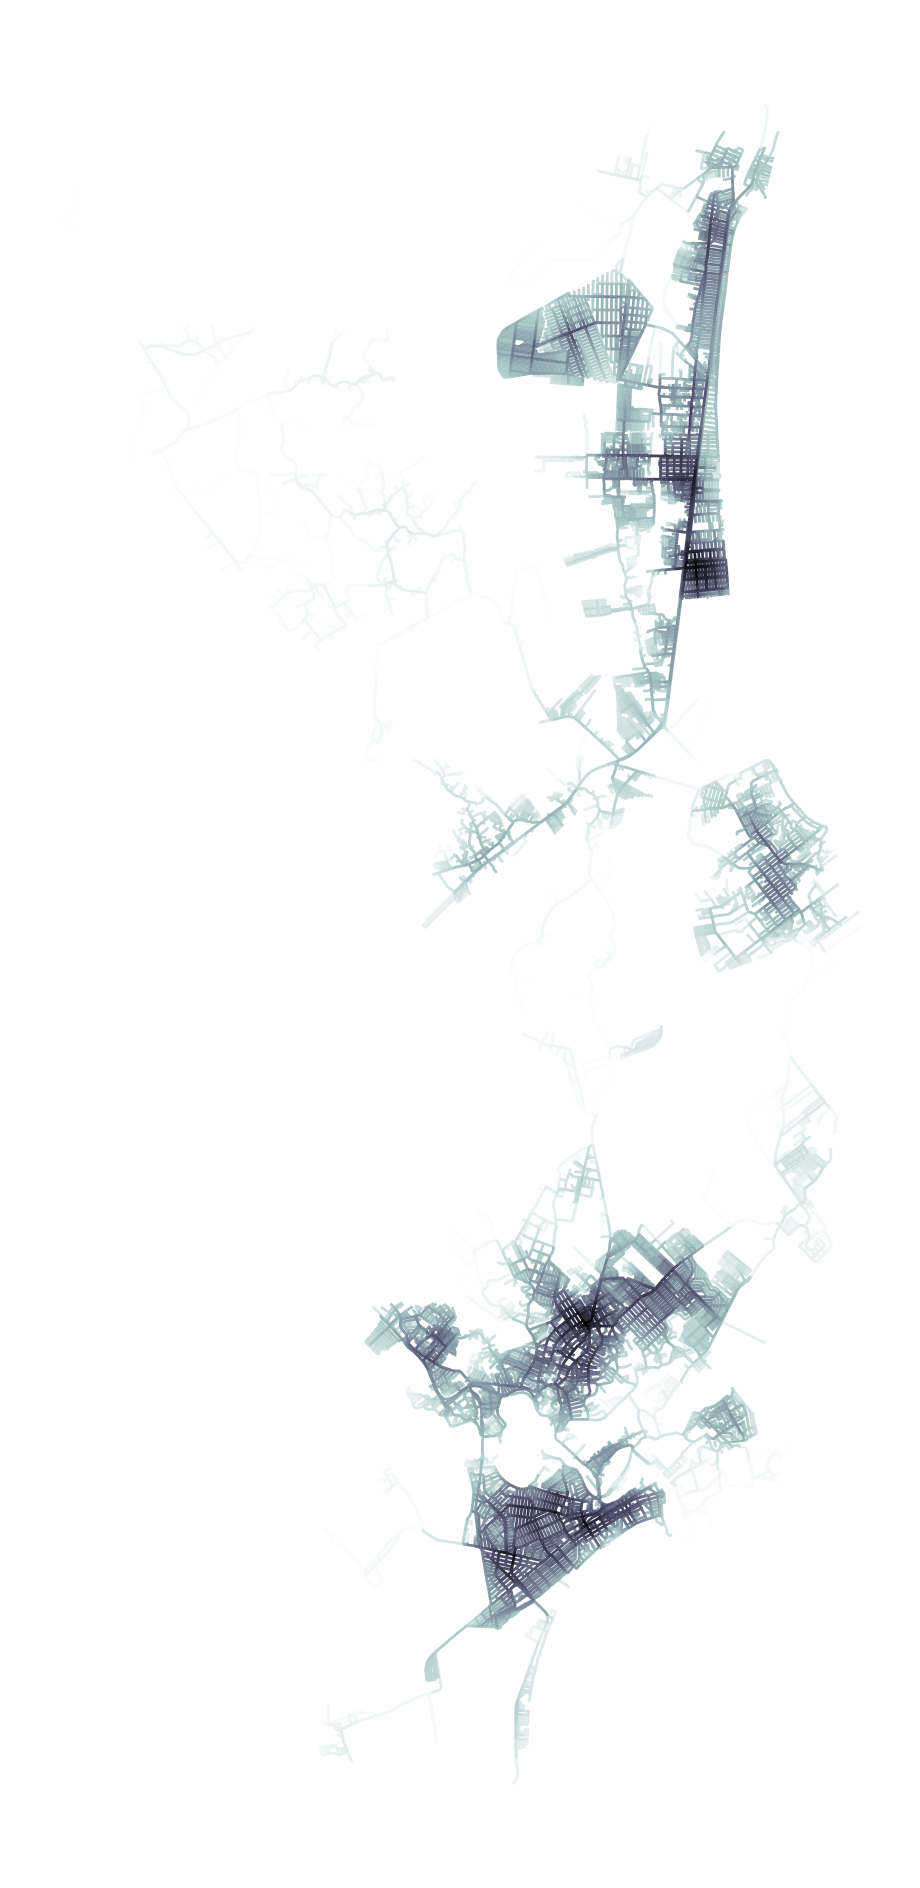

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_hillier_1000_ang"
nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="bone_r",
    #cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)

plt.show()

In [27]:
cx.providers.CartoDB.Positron

{'url': 'https://{s}.basemaps.cartocdn.com/{variant}/{z}/{x}/{y}{r}.png',
 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
 'attribution': '(C) OpenStreetMap contributors (C) CARTO',
 'subdomains': 'abcd',
 'max_zoom': 20,
 'variant': 'light_all',
 'name': 'CartoDB.Positron'}

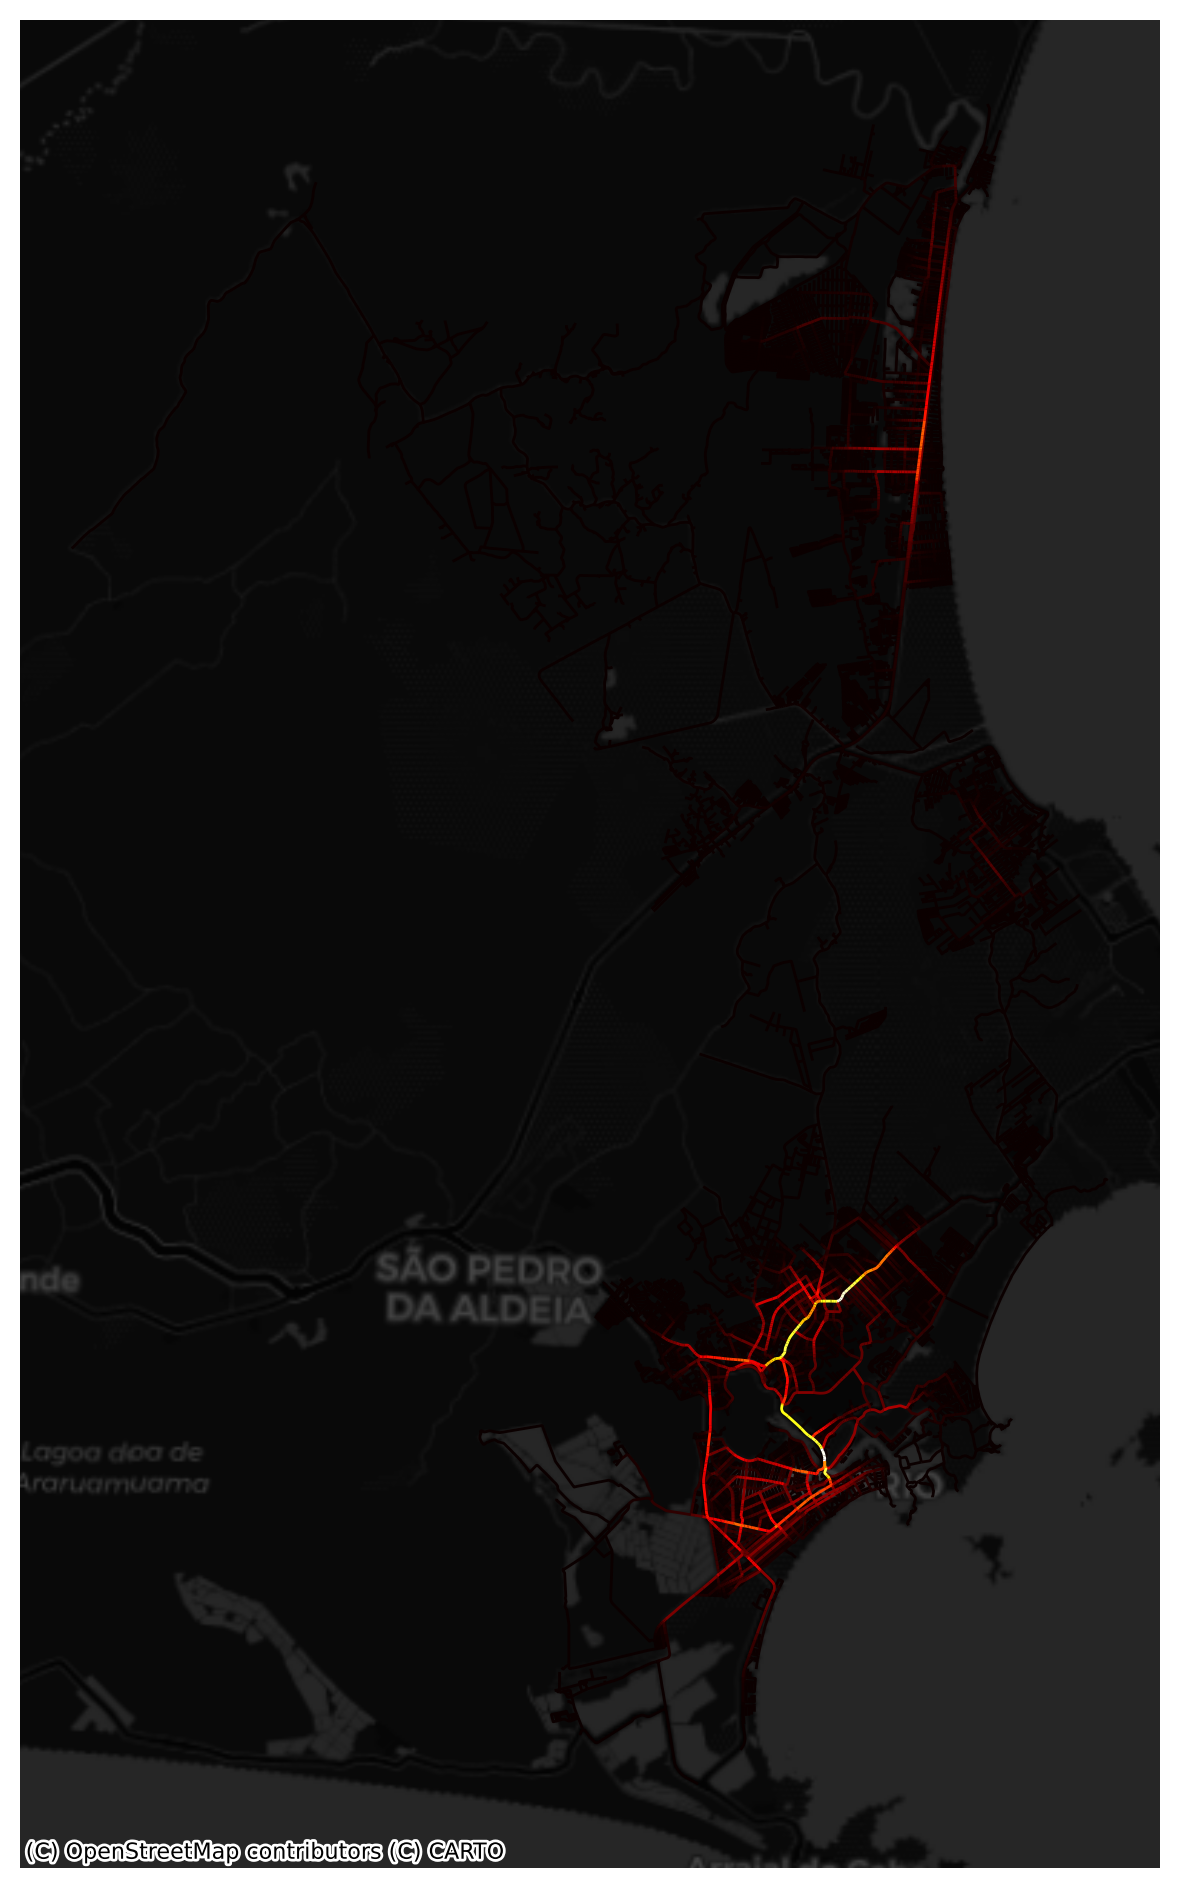

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_betweenness_5000_ang"
weighted_nodes_gdf.sort_values(metric).plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="hot",
    #cmap='inferno',
    legend=False,
    #scheme='JenksCaspall',
    ax=ax,
    linewidth=1,
)

ax.axis(False)
cx.add_basemap(
    ax=ax,
    crs=weighted_nodes_gdf.crs,
    source=cx.providers.CartoDB.DarkMatter,
)

plt.show()

# Diversity

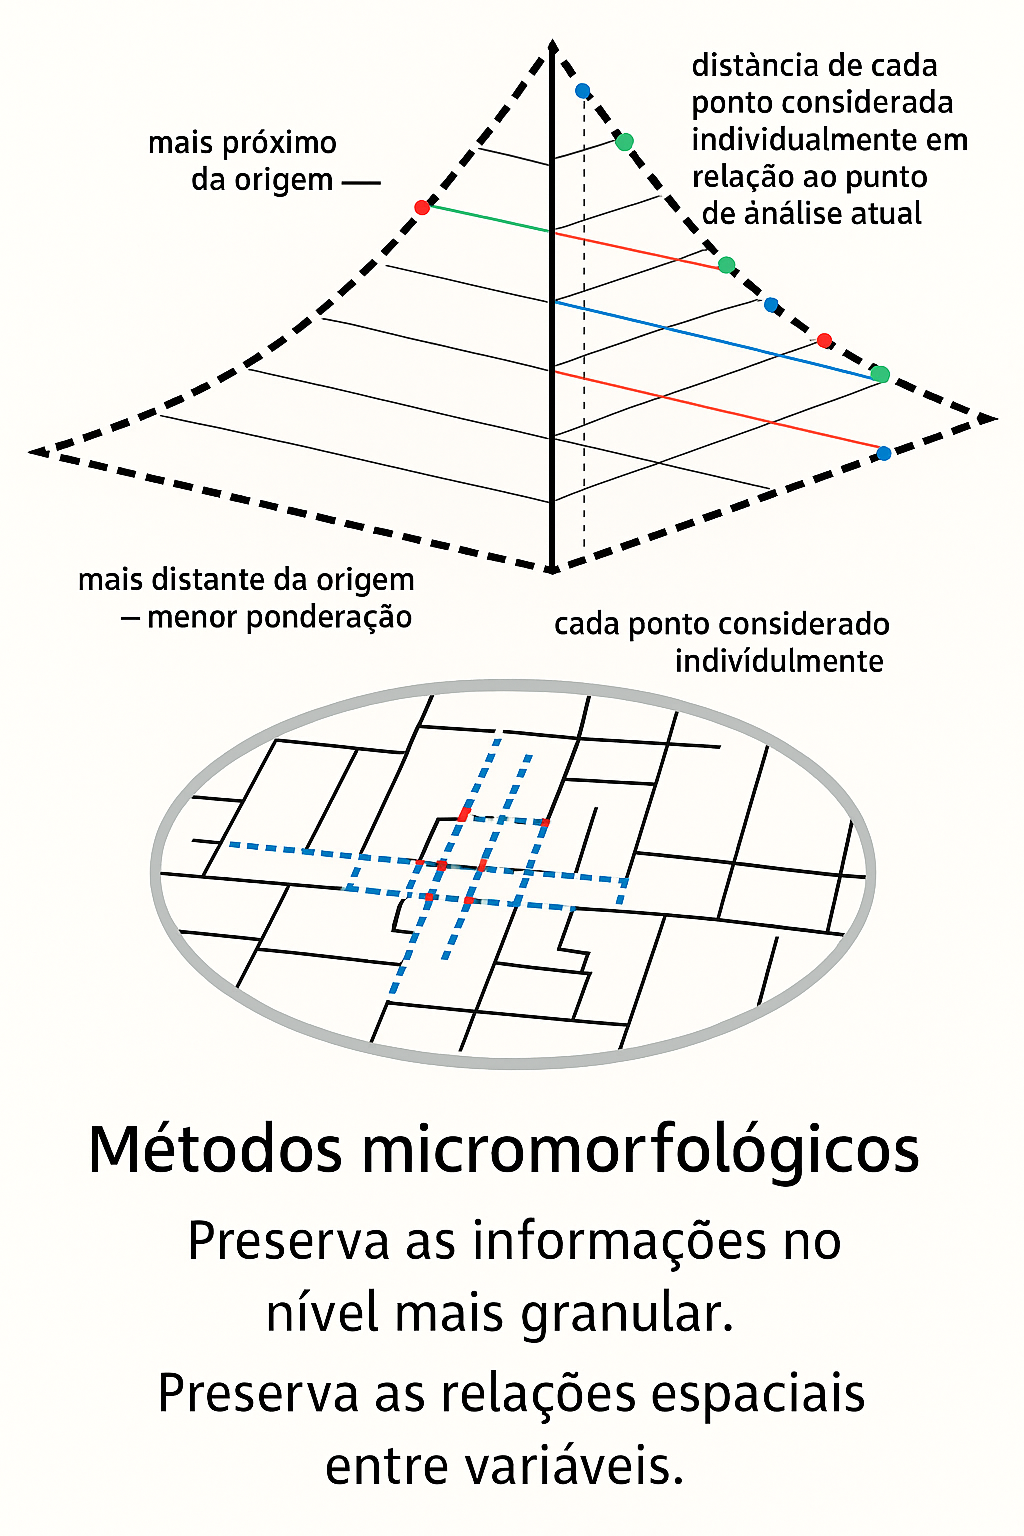

In [29]:
# TODO: não chamar de cnae_division para melhor alinhas
# com as divisoes do próprio cnae
rais['cnae_division'] = rais.cnae_2.str.extract(r"(\d{3}).")
premises_gpd = rais.dropna(subset=['cnae_division'])

In [30]:
# TODO: não chamar de cnae_division para melhor alinhas
# com as divisoes do próprio cnae
premises_gpd = rais.dropna(subset=['cnae_2']).dropna(subset=['cnae_2'])

In [31]:
nodes_gdf, prems_gpd = layers.compute_mixed_uses(
    premises_gpd,
    landuse_column_label="cnae_2",
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=distances,
)

INFO:cityseer.metrics.layers:Computing mixed-use measures.
INFO:cityseer.metrics.layers:Assigning data to network.
INFO:cityseer.data:Assigning 9459 data entries to network nodes (max_dist: 100).
INFO:cityseer.data:Finished assigning data. 13349 assignments added to 1142 nodes.
100%|██████████| 15175/15175 [00:35<00:00, 429.64it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 250m, Beta: 0.016, Walking Time: 3.1333333333333333 minutes.
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.
INFO:cityseer.config:Distance: 10000m, Beta: 0.0004, Walking Time: 125.0 minutes.
INFO:cityseer.config:Distance: 20000m, Beta: 0.0002, Walking Time: 250.0 minutes.


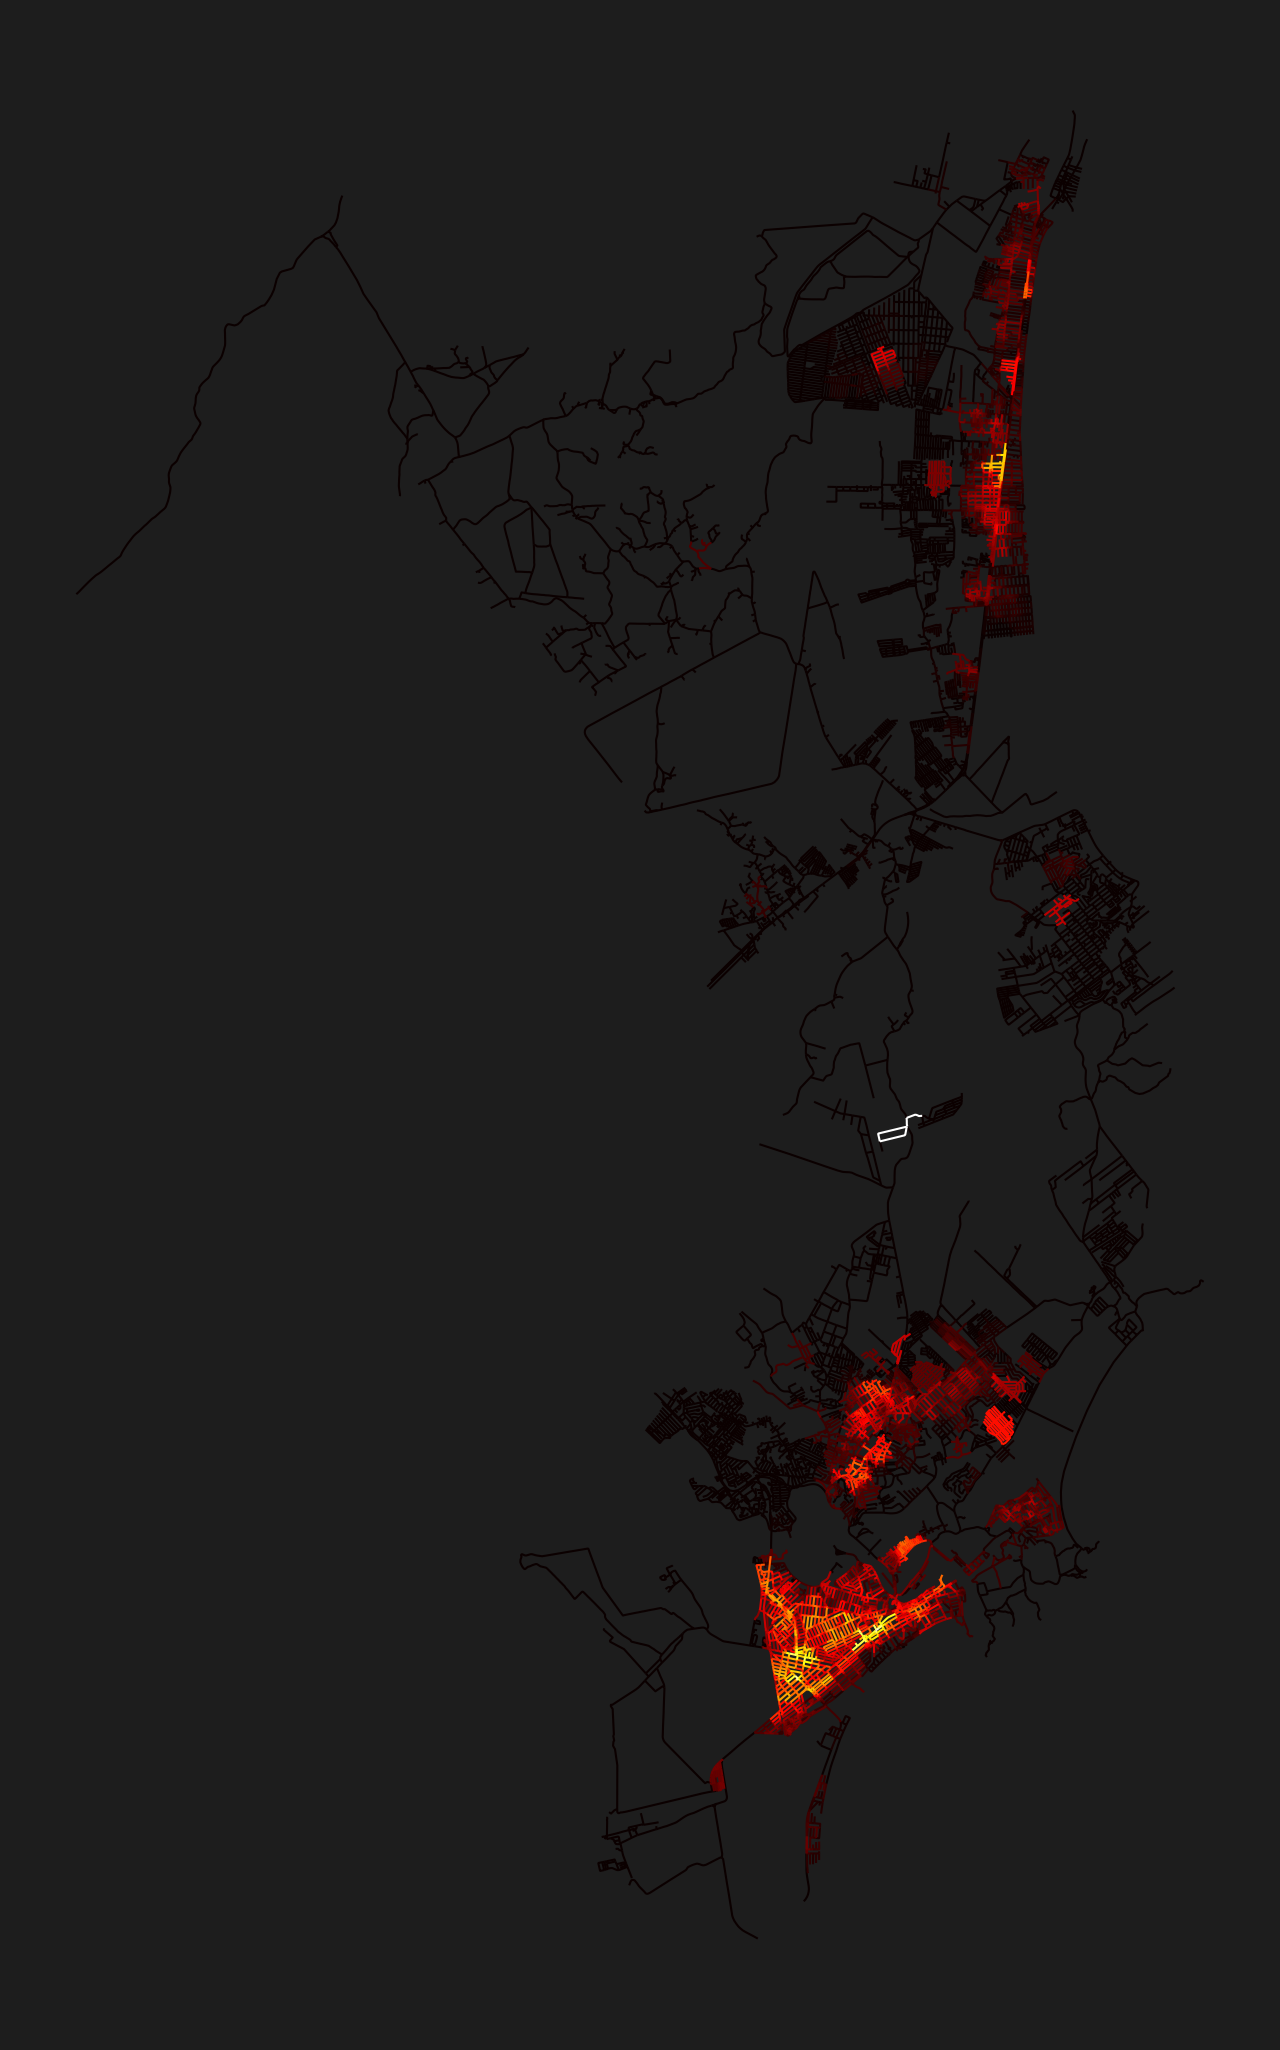

In [32]:
metric = "cc_hill_q1_500_wt"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
nodes_gdf.sort_values(metric).plot(
    column=metric,
    cmap="hot",
    legend=False,
    ax=ax,
    linewidth=.75,
)

ax.axis(False)
plt.show()

# Avançado: Kepler

Para visualizações interativas mais ricas, pode-se utilizar o Kepler.gl para Jupyter.
Ele permite explorar grandes redes urbanas com escalas de cores, filtros e interações gráficas de forma intuitiva. Mais mportante, nesse caso, ele permite visualizações mais fluidas e que não consomem a memória de forma tão gritante como no caso do Folium e do Plotly (boas bibliotecas de visualização, mas que pesam no carregamento de muitos elementos, como é o caso de uma rede viária.)

Contudo, a instalação do keplergl em Jupyter pode ser um pouco mais trabalhosa para quem está começando. Isso acontece porque ele depende de widgets — pequenos componentes gráficos que conectam o código Python ao que aparece na tela (por exemplo, botões, caixas de seleção ou mapas interativos). Para que funcionem corretamente, é preciso que o ambiente Jupyter tenha suporte a esses widgets instalado e configurado.

Por esse motivo, apresentamos este recurso apenas como uso avançado. Para usuários do Kit Básico do Mob4.0, a instalação precisa ser feita à parte e não está contida no arquivo ambiente_roda.yaml.

As instruções oficiais de instalação e configuração estão disponíveis na documentação do Kepler.gl:

👉 [Kepler.gl Jupyter – Installation Guide](https://docs.kepler.gl/docs/keplergl-jupyter#kepler.gl-for-jupyter-user-guide)

In [33]:
# Load an empty map
from keplergl import KeplerGl

